In [2]:
import pandas as pd
import polars as pl
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import npc_lims
# from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils
import lazynwb

from sklearn.preprocessing import StandardScaler

import os
import pickle
import upath

%load_ext autoreload
%autoreload 2
# %matplotlib widget

In [3]:
# get list of sessions to run on
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_good_behavior_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

templeton_session_list=(
    session_table.filter(
    pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    )['session_id'].to_list()
)

In [12]:
len(dr_good_behavior_list)
dr_good_behavior_list[25:26]

array(['662892_2023-08-23'], dtype=object)

In [4]:
#generate ITIs with same statistics as the task

def generate_DR_ITI(n_samples=None,is_templeton=False):

    import random

    preStimFramesFixed = 90 # min frames between start of trial and stimulus onset
    preStimFramesVariableMean = 60 # mean of additional preStim frames drawn from exponential distribution
    preStimFramesMax = 360 # max total preStim frames
    # quiescentFrames = 90 # frames before stim onset during which licks delay stim onset
    responseWindow = [6,60]
    postResponseWindowFrames = 180

    if is_templeton:
        preStimFramesVariableMean = 30 
        preStimFramesMax = 240
        postResponseWindowFrames = 120

    if n_samples is not None:
        return [generate_DR_ITI(is_templeton=is_templeton) for _ in range(n_samples)]
    else:
        val = preStimFramesFixed + random.expovariate(1/preStimFramesVariableMean) if preStimFramesVariableMean > 1 else preStimFramesFixed + preStimFramesVariableMean
        trial_total_length = (int(min(val,preStimFramesMax)) + responseWindow[1] + postResponseWindowFrames)/60 #in seconds

        return trial_total_length


def plot_corr_matrix(corr_matrix, block_switch_indices, sel_session, is_upsampled, colorscale=0.2, colormap='viridis', savepath=None, closefig=False):

    if is_upsampled:
        title_suffix="upsampled"
    else:
        title_suffix=""

    fig,ax=plt.subplots(1,1,figsize=(7,6))

    im=ax.imshow(corr_matrix, vmin=-colorscale, vmax=colorscale, cmap=colormap, interpolation='none', origin='lower', aspect='equal')

    for switch_idx in block_switch_indices:
        ax.axvline(switch_idx, color='black', linestyle='-', alpha=1.0, linewidth=0.75)
        ax.axhline(switch_idx, color='black', linestyle='-', alpha=1.0, linewidth=0.75)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation coefficient')

    ax.set_ylabel('trials')
    ax.set_xlabel('trials')
    ax.set_title(f'Correlation matrix of neural activity across trials\nall units {title_suffix}; {sel_session}')

    if savepath is not None:
        plt.savefig(os.path.join(savepath, f'corr_matrix_session_{sel_session}_{title_suffix}.png'), dpi=300, bbox_inches='tight')
    if closefig:
        plt.close(fig)

In [15]:
#calculate population vector correlations across trials for each session in dr_good_behavior_list

context_module_areas=['ACAd','PL','ORBl','ORBvl','ILA','AId','AIp','FRP','MOs','MOp','SSs','SSp','CP',
                      'SCig','SCiw','SCdg','SCdw','MRN','RN','PAG','GPe','GPi','SNr','SNc','VTA','ZI',
                      'VM','VISC','SMT','PIL','GU','VPLpc','HPF','MB','TH','ICe','DP','APN','Eth','CL',
                      'AD','VPL','TEa','ACB','SF','POL','RT','MD','VISam']

# non_context_module_areas=['VISp','VISl','VISal','VISrl','VISam','VISpm','LGd','LP',
#                           'CA1','CA2','CA3','DG','RSPd','RSPv','RSPagl','LSr','LSc']

savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations - strict presence ratio"

# all_spont_task_trial_dfs = {}
# all_corr_matrices = {}
# all_upsampled_block_labels = {}
# all_upsampled_corr_matrices = {}

all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect().to_pandas()
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect().to_pandas()

upsample_n=200

is_templeton=False

if is_templeton:
    session_list=templeton_session_list
else:
    session_list=dr_good_behavior_list

for sel_session in session_list[:]:

    #require 2 pre-task and 2 post-task spontaneous epochs
    epochs=pd.read_parquet(npc_lims.get_cache_path(nwb_component='epochs', session_id=sel_session, version='0.0.272'))
    # epoch_counts=epochs['script_name'].value_counts()
    # if epoch_counts.get('Spontaneous',0)<1 or epoch_counts.get('SpontaneousRewards',0)<2:
    #     print(f"Session {sel_session} does not have enough spontaneous epochs, skipping")
    #     continue

    session_info=npc_lims.get_session_info(sel_session)
    trials=all_trials.query('session_id==@sel_session').sort_values('start_time').reset_index(drop=True)
    performance=all_performance.query('session_id==@sel_session').sort_values('start_time').reset_index(drop=True)
    units=data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

    if is_templeton:
        #make false blocks, 6 evenly spaced with random starting modality
        session_start=trials['start_time'].min()
        session_end=trials['stop_time'].max()
        block_edges=np.linspace(session_start, session_end, 7) # 6 blocks
        block_labels=np.arange(len(block_edges)-1)

        first_block_modality=np.random.choice(['vis','aud'])
        if first_block_modality=='vis':
            block_modalities=['vis','aud']*3
        else:
            block_modalities=['aud','vis']*3

        trials['block_index'] = pd.cut(trials['start_time'], bins=block_edges, labels=block_labels, include_lowest=True).to_numpy()
        trials['is_block_switch'] = trials['block_index']!=trials['block_index'].shift(1)
        trials['rewarded_modality'] = trials['block_index'].map(lambda x: block_modalities[x])


    path = 's3://aind-scratch-data/dynamic-routing/cache/nwb/v0.0.272/{session_id}.nwb'
    internal_path = 'processing/behavior/rewards'
    rewards = lazynwb.get_df(path.format(session_id=sel_session), internal_path, as_polars=False)

    #make data array

    units_filtered = units.query(
        'presence_ratio>=0.95 and \
        isi_violations_ratio<=0.5 and \
        amplitude_cutoff<=0.1 and \
        activity_drift<=0.1 and \
        firing_rate>=0.5 and \
        ~structure.isna() and ~location.isna()'
        ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])
    
    if len(units_filtered)==0:
        print(f"No units passed quality control for session {sel_session}, skipping")
        continue

    time_before = 1.5
    time_after = 0.01
    binsize = 1.5
    trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize)

    #get spontaneous equivalent to trial_da - generate false trials using itis
    # epochs.query('script_name.str.contains("Spontaneous")') #spont with & without rewards
    # epochs.query('script_name=="Spontaneous"')

    # if no spont epochs, skip spont analysis
    if epochs.query('script_name.str.contains("Spontaneous")').empty:

        spont_task_da = trial_da.copy()
        spont_task_trial_df = trials.copy()
    
    else:

        time_before = 1.5
        time_after = 0.01
        binsize = 1.5

        min_ITI=5.5

        spont_trials={
            'start_time':[],
            'epoch_idx':[],
            'epoch_name':[],
            'is_rewarded':[]
        }

        task_index=epochs.query('script_name=="DynamicRouting1"').index[0]

        for rr,row in epochs.query('script_name.str.contains("Spontaneous")').iterrows():
            spont_start=row['start_time']
            spont_end=row['stop_time']
            spont_duration=spont_end-spont_start
            
            sampleITIs=generate_DR_ITI(n_samples=1000,is_templeton=False)
            cum_sampleITIs=np.cumsum(sampleITIs)
            valid_starts=spont_start+cum_sampleITIs[cum_sampleITIs+spont_start<spont_end]
            is_rewarded=np.zeros(len(valid_starts),dtype=bool)

            #find rewards and align trials to them, prevent any overlapping trials
            reward_times=rewards.query('timestamps>=@spont_start and timestamps<=@spont_end')['timestamps'].to_numpy()
            if len(reward_times)>0:
                #remove any valid_starts that would overlap with reward times
                for rt in reward_times:
                    incl_idx=np.abs(valid_starts-rt)>(min_ITI)
                    valid_starts=valid_starts[incl_idx]
                    is_rewarded= is_rewarded[incl_idx]
                #add trials aligned to rewards
                valid_starts = np.concatenate([valid_starts, reward_times])
                is_rewarded = np.concatenate([is_rewarded, np.ones(len(reward_times), dtype=bool)])

            spont_trials['start_time'].append(valid_starts)
            spont_trials['epoch_idx'].append(np.repeat(rr,len(valid_starts)))
            spont_trials['epoch_name'].append(np.repeat(row['script_name'],len(valid_starts)))
            spont_trials['is_rewarded'].append(is_rewarded)

        spont_trials['start_time'] = np.concatenate(spont_trials['start_time'])
        spont_trials['epoch_idx'] = np.concatenate(spont_trials['epoch_idx'])
        spont_trials['epoch_name'] = np.concatenate(spont_trials['epoch_name'])
        spont_trials['is_rewarded'] =  np.concatenate(spont_trials['is_rewarded'])

        spont_trials_df = pd.DataFrame(spont_trials).sort_values('start_time').reset_index(drop=True)
        spont_trial_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, spont_trials_df, time_before, time_after, binsize, event_name='start_time')

        trials.loc[0,'is_block_switch']=True

        is_spont_block_switch=[]
        for _,tr in spont_trials_df.iterrows():
            if _==0:
                is_spont_block_switch.append(False)
            else: 
                is_spont_block_switch.append(tr['epoch_idx']!=spont_trials_df.iloc[_-1]['epoch_idx'])
        spont_trials_df['is_block_switch']=is_spont_block_switch

        task_start_time=trials.iloc[0]['start_time']
        pretask_spont_trials=spont_trials_df.query('start_time < @task_start_time').index.values
        posttask_spont_trials=spont_trials_df.query('start_time >= @task_start_time').index.values

        spont_task_da = xr.concat([
            spont_trial_da.sel(trials=pretask_spont_trials), 
            trial_da, 
            spont_trial_da.sel(trials=posttask_spont_trials)], 
            dim='trials')
        spont_task_trial_df = pd.concat([
            spont_trials_df.query('start_time < @task_start_time'), 
            trials, 
            spont_trials_df.query('start_time >= @task_start_time')
            ], ignore_index=True).sort_values('start_time').reset_index(drop=True)
    

    block_switch_indices=np.where(spont_task_trial_df['is_block_switch'].values)[0]

    spont_task_trial_df.to_parquet(os.path.join(savepath, 'trial_df', f'spont_task_trial_df_session_{sel_session}.parquet'))

    for is_context_module in [True,False]:

        context_module_str="context_module" if is_context_module else "non_context_module"

        if is_context_module:
            sel_units=units_filtered.query('structure.isin(@context_module_areas)')
        else:
            sel_units=units_filtered.query('~structure.isin(@context_module_areas)')

        if len(sel_units)==0:
            print(f"No units found for session {sel_session} and context_module={is_context_module}, skipping")
            continue

        sel_data=spont_task_da.sel(unit_id=sel_units['unit_id'].values)

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(sel_data.data.reshape(sel_data.data.shape[0], -1).T)

        corr_matrix=np.corrcoef(scaled_data)
        
        upsampled_block_labels=[]
        interp_data=[]

        if block_switch_indices[0]==0:
            block_indices=np.concatenate([block_switch_indices, [len(spont_task_trial_df)]])
        else:
            block_indices=np.concatenate([[0], block_switch_indices, [len(spont_task_trial_df)]])

        for bb in range(1,len(block_indices)):

            block_data=scaled_data[block_indices[bb-1]:block_indices[bb],:]
            block_data_interp=np.zeros((upsample_n, block_data.shape[1]))
            for uu in range(block_data.shape[1]):
                block_data_interp[:,uu] = np.interp(np.linspace(0, block_data.shape[0]-1, upsample_n), np.arange(block_data.shape[0]), block_data[:,uu])
            interp_data.append(block_data_interp)
            upsampled_block_labels.append(np.repeat([bb-1], upsample_n))

        interp_data=np.concatenate(interp_data,axis=0)
        upsampled_block_labels=np.concatenate(upsampled_block_labels)

        upsampled_block_switch_indices=np.where(np.diff(upsampled_block_labels)!=0)[0]+1

        corr_matrix_scaled=np.corrcoef(interp_data)

        # all_spont_task_trial_dfs[sel_session]=spont_task_trial_df
        # all_corr_matrices[sel_session]=corr_matrix
        # all_upsampled_corr_matrices[sel_session]=corr_matrix_scaled
        # all_upsampled_block_labels[sel_session]=upsampled_block_labels

        plot_corr_matrix(corr_matrix, block_switch_indices, f'{sel_session}_{context_module_str}', is_upsampled=False, colorscale=0.2, savepath=savepath, closefig=True)
        plot_corr_matrix(corr_matrix_scaled, upsampled_block_switch_indices, f'{sel_session}_{context_module_str}', is_upsampled=True, colorscale=0.2, savepath=savepath, closefig=True)

        #change to save parquet files for each session instead of pickling everything at the end, to avoid memory issues
        
        corr_matrix_df = pd.DataFrame({
            'session_id': [sel_session],
            'corr_matrix_as_array': [corr_matrix.flatten()],
            'corr_matrix_shape': [corr_matrix.shape],
            'epoch_names': [epochs['script_name'].values],
            'epoch_idx': [epochs.index.values],
            'is_context_module': is_context_module,
        })
        corr_matrix_df.to_parquet(os.path.join(savepath, 'corr_matrix_original', f'corr_matrix_session_{sel_session}_{context_module_str}.parquet'))

        upsampled_corr_matrix_df = pd.DataFrame({
            'session_id': [sel_session],
            'upsampled_block_labels': [upsampled_block_labels],
            'corr_matrix_as_array': [corr_matrix_scaled.flatten()],
            'corr_matrix_shape': [corr_matrix_scaled.shape],
            'epoch_names': [epochs['script_name'].values],
            'epoch_idx': [epochs.index.values],
            'is_context_module': is_context_module,
        })
        upsampled_corr_matrix_df.to_parquet(os.path.join(savepath, 'corr_matrix_upsampled', f'upsampled_corr_matrix_session_{sel_session}_{context_module_str}.parquet'))

    print(f"Finished session {sel_session}")

# #save results

# pickle_save_path=os.path.join(savepath, "population_vector_correlation_results.pkl")
# with open(pickle_save_path, 'wb') as f:
#     pickle.dump({
#         'all_spont_task_trial_dfs': all_spont_task_trial_dfs,
#         'all_corr_matrices': all_corr_matrices,
#         'all_upsampled_block_labels': all_upsampled_block_labels,
#         'all_upsampled_corr_matrices': all_upsampled_corr_matrices
#     }, f)


626791_2022-08-15 cached units loaded
Finished session 626791_2022-08-15
626791_2022-08-16 cached units loaded
Finished session 626791_2022-08-16
636766_2023-01-23 cached units loaded
Finished session 636766_2023-01-23
636766_2023-01-24 cached units loaded
Finished session 636766_2023-01-24
636766_2023-01-25 cached units loaded
Finished session 636766_2023-01-25
636766_2023-01-26 cached units loaded
Finished session 636766_2023-01-26
644864_2023-01-30 cached units loaded
Finished session 644864_2023-01-30
644864_2023-01-31 cached units loaded
Finished session 644864_2023-01-31
644864_2023-02-02 cached units loaded
Finished session 644864_2023-02-02
644866_2023-02-07 cached units loaded
No units passed quality control for session 644866_2023-02-07, skipping
644866_2023-02-08 cached units loaded
Finished session 644866_2023-02-08
644866_2023-02-09 cached units loaded
Finished session 644866_2023-02-09
644866_2023-02-10 cached units loaded
Finished session 644866_2023-02-10
649943_2023-02

In [63]:
# block_indices
# block_switch_indices[0]!=0
len(spont_task_trial_df)

673

In [47]:
# np.linspace(session_start, session_end, 7)
# trials['block_index']!=trials['block_index'].shift(1)
np.where(trials['block_index']!=trials['block_index'].shift(1))[0]

array([  0,  91, 179, 270, 361, 452], dtype=int64)

In [45]:
trials['block_index'][91]

1

In [25]:
# sel_data
# is_context_module
# sel_units['structure'].unique()
units_filtered

,activity_drift,amplitude,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,ccf_ap,ccf_dv,ccf_ml,channels,...,unit_id,velocity_above,velocity_below,spike_times,obs_intervals,electrodes,session_idx,date,subject_id,session_id
id,,,,,,,,,,,,,,,,,,,,,


In [27]:
epochs

,start_time,stop_time,script_name,notes,interval_names,tags,session_idx,date,subject_id,session_id
id,,,,,,,,,,
0,43.72048,914.433659,RFMapping,,"[vis_rf_mapping_trials, aud_rf_mapping_trials]",[mapping],0,2025-02-07,759434,759434_2025-02-07
1,925.29370,1528.481261,Spontaneous,,[spontaneous_trials],[spontaneous],0,2025-02-07,759434,759434_2025-02-07
2,1538.55595,2141.694798,SpontaneousRewards,,[spontaneous_rewards_trials],"[rewards, spontaneous]",0,2025-02-07,759434,759434_2025-02-07
3,2151.63633,5796.756819,DynamicRouting1,,"[trials, performance]","[task, rewards]",0,2025-02-07,759434,759434_2025-02-07
4,5807.88298,6411.004833,SpontaneousRewards,,[spontaneous_rewards_trials],"[rewards, spontaneous]",0,2025-02-07,759434,759434_2025-02-07
5,6421.28015,7024.435453,Spontaneous,,[spontaneous_trials],[spontaneous],0,2025-02-07,759434,759434_2025-02-07


In [ ]:
epochs.query('script_name=="DynamicRouting1"').index[0]

In [ ]:
### need to update loading code! load lazily with polars, then do mean in the query before collecting, to minimize memory usage
# then reshape the array after getting the mean

In [5]:
import pathlib

# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations - templeton"
# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations v2"
# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations v3 - 1.5s more context module areas"
savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations - strict presence ratio"

upscaled_corr_matrix_path=pathlib.Path(os.path.join(savepath, "corr_matrix_upsampled"))

#corr matrix with 2 pre and 2 post task spont epochs
corr_matrix_as_array=(
    pl.scan_parquet(upscaled_corr_matrix_path)
    .filter(
        pl.col('is_context_module')==True,
        pl.col('upsampled_block_labels').list.n_unique()==10
    )
    .select(
        pl.col('session_id'),
        pl.col('corr_matrix_shape'),
        pl.col('corr_matrix_as_array'),
    )
).collect().to_pandas()


In [6]:
corr_matrix_mean=np.nanmean(np.vstack(corr_matrix_as_array['corr_matrix_as_array'].values),axis=0).reshape(corr_matrix_as_array['corr_matrix_shape'].values[0])

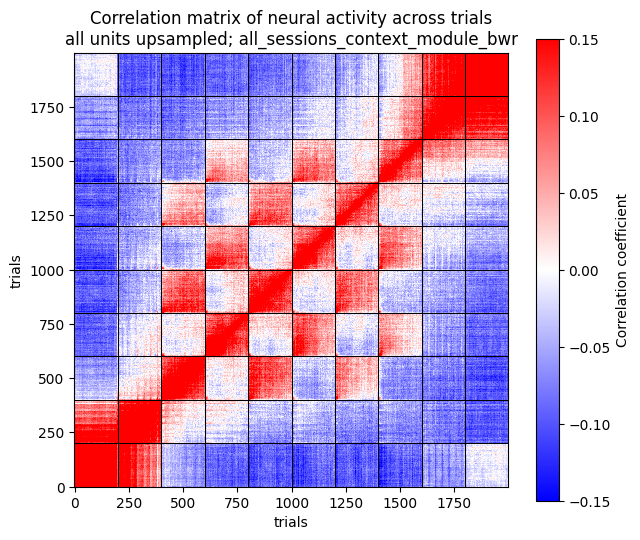

In [7]:
# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations v2"
# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations v3 - 1.5s more context module areas"
block_switches=np.arange(0, corr_matrix_mean.shape[0], corr_matrix_mean.shape[0]//10)[1:]
title_str="all_sessions_context_module_bwr"
plot_corr_matrix(corr_matrix_mean, block_switches, title_str, is_upsampled=True, colorscale=0.15, colormap='bwr', savepath=None, closefig=False)

In [ ]:
### Averages: need to happen at the individual session level, then average across sessions

#average within-block correlation (task vs spontaneous)

#average within-same-block-type correlation (spont-spont, task vis-task vis)

#average cross-block correlation (spont-task, vis-task-aud-task)


In [169]:
# savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations - templeton"
savepath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\population vector correlations v3 - 1.5s more context module areas"

upscaled_corr_matrix_path=pathlib.Path(os.path.join(savepath, "corr_matrix_upsampled"))

corr_matrix_all=pl.scan_parquet(upscaled_corr_matrix_path).filter(pl.col('is_context_module')==True).collect().to_pandas()

In [170]:
# corr_matrix_all.iloc[29]
upscaled_corr_matrix_path

WindowsPath('//allen/programs/mindscope/workgroups/dynamicrouting/Ethan/population vector correlations v3 - 1.5s more context module areas/corr_matrix_upsampled')

In [171]:
#average across task only (includes more sessions)

corr_matrix_task_only=[]

for rr,row in corr_matrix_all.iterrows():

    # row=corr_matrix_all.iloc[29]

    if row.corr_matrix_shape[0]==1200:
        corr_matrix_shape=row.corr_matrix_shape
        corr_matrix_as_array=row.corr_matrix_as_array
        corr_matrix=corr_matrix_as_array.reshape(corr_matrix_shape)
        corr_matrix_task_only.append(corr_matrix)
        continue

    epoch_names=row.epoch_names
    epoch_idx=row.epoch_idx
    corr_matrix_shape=row.corr_matrix_shape
    corr_matrix_as_array=row.corr_matrix_as_array

    corr_matrix=corr_matrix_as_array.reshape(corr_matrix_shape)

    task_epoch_indices=np.where(epoch_names=='DynamicRouting1')[0]

    n_pre_task_spont_epochs=np.isin(epoch_names[epoch_idx<task_epoch_indices[0]],['Spontaneous','SpontaneousRewards']).sum()
    n_post_task_spont_epochs=np.isin(epoch_names[epoch_idx>task_epoch_indices[-1]],['Spontaneous','SpontaneousRewards']).sum()

    if n_pre_task_spont_epochs==2 and corr_matrix_shape[0]>=1600:
        corr_matrix=corr_matrix[400:1600,400:1600]
    elif n_pre_task_spont_epochs==1 and corr_matrix_shape[0]>=1400:
        corr_matrix=corr_matrix[200:1400,200:1400]
    else:
        continue

    corr_matrix_task_only.append(corr_matrix)

In [172]:
# corr_matrix_shape
# n_pre_task_spont_epochs

In [173]:
corr_matrix_mean=np.nanmean(np.stack(corr_matrix_task_only,axis=2),axis=2)

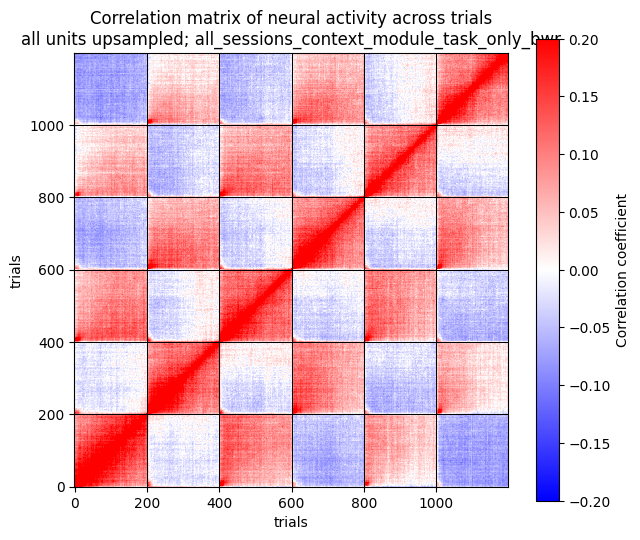

In [ ]:
block_switches=np.arange(0, corr_matrix_mean.shape[0], corr_matrix_mean.shape[0]//6)[1:]
title_str="all_sessions_context_module_task_only_bwr"
plot_corr_matrix(corr_matrix_mean, block_switches, title_str, is_upsampled=True, colorscale=0.2, colormap='bwr', savepath=None, closefig=False)

In [ ]:
# make 2 means: 
# one with sessions with only 1 post-task spontaneous epoch (excluding 2nd spont epoch for those that have it)
# the other with sessions with 2 post-task spontaneous epochs

session_ids=list(all_upsampled_block_labels.keys())

has_2_pre_2_post_spont_epochs=[]
has_2_pre_1_post_spont_epochs=[]

all_epochs=pd.read_parquet(npc_lims.get_cache_path(nwb_component='epochs', version='0.0.272'))

for sel_session in session_ids:
    epochs=all_epochs.query('session_id==@sel_session').sort_values('start_time').reset_index(drop=True)
    task_epoch_idx=epochs.query('script_name=="DynamicRouting1"').index[0]
    n_spont_epochs_pre=np.sum(epochs.query('index < @task_epoch_idx')['script_name'].str.contains('Spontaneous'))
    n_spont_epochs_post=np.sum(epochs.query('index > @task_epoch_idx')['script_name'].str.contains('Spontaneous'))

    if n_spont_epochs_pre==2 and n_spont_epochs_post==2:
        has_2_pre_2_post_spont_epochs.append(sel_session)
        has_2_pre_1_post_spont_epochs.append(sel_session) #also include in 1 post group since they have 2
    elif n_spont_epochs_pre==2 and n_spont_epochs_post==1:
        has_2_pre_1_post_spont_epochs.append(sel_session)



In [ ]:
#compute mean heatmap for sessions with 2 pre and 1 post spont epoch
sum_2_pre_1_post_matrices=np.zeros((
    all_upsampled_corr_matrices[has_2_pre_1_post_spont_epochs[0]].shape[0], 
    all_upsampled_corr_matrices[has_2_pre_1_post_spont_epochs[0]].shape[1],
))

n_2_pre_1_post=0
for ss,sel_session in enumerate(has_2_pre_1_post_spont_epochs):

    temp_corr_matrix=all_upsampled_corr_matrices[sel_session]
    temp_block_labels=all_upsampled_block_labels[sel_session]
    unique_block_labels=np.unique(temp_block_labels)
    
    if sel_session in has_2_pre_2_post_spont_epochs:
        temp_corr_matrix=temp_corr_matrix[temp_block_labels<unique_block_labels[-1],temp_block_labels<unique_block_labels[-1]] #remove last spont block
        temp_block_labels=temp_block_labels[temp_block_labels<unique_block_labels[-1]]
        unique_block_labels=np.unique(temp_block_labels)

    if len(unique_block_labels)!=9:
        print(f"Session {sel_session} does not have 9 blocks, skipping")
        continue

    sum_2_pre_1_post_matrices+=temp_corr_matrix
    n_2_pre_1_post+=1

mean_all_2_pre_1_post_matrix=sum_2_pre_1_post_matrices / n_2_pre_1_post


#compute mean heatmap for sessions with 2 pre and 2 post spont epochs
sum_2_pre_2_post_matrices=np.zeros((
    all_upsampled_corr_matrices[has_2_pre_2_post_spont_epochs[0]].shape[0],
    all_upsampled_corr_matrices[has_2_pre_2_post_spont_epochs[0]].shape[1],
))

n_2_pre_2_post=0
for ss,sel_session in enumerate(has_2_pre_2_post_spont_epochs):

    temp_corr_matrix=all_upsampled_corr_matrices[sel_session]
    temp_block_labels=all_upsampled_block_labels[sel_session]
    unique_block_labels=np.unique(temp_block_labels)
    if len(unique_block_labels)!=10:
        print(f"Session {sel_session} does not have 10 blocks, skipping")
        continue

    sum_2_pre_2_post_matrices+=temp_corr_matrix
    n_2_pre_2_post+=1

mean_all_2_pre_2_post_matrix=sum_2_pre_2_post_matrices / n_2_pre_2_post



In [ ]:
all_2_pre_1_post_matrices=[]
all_2_pre_2_post_matrices=[]

In [ ]:
# unique_block_labels
# temp_block_labels<unique_block_labels[-1]
temp_corr_matrix[temp_block_labels<unique_block_labels[-1],temp_block_labels<unique_block_labels[-1]]

In [ ]:
np.min(mean_all_2_pre_1_post_matrix)
n_2_pre_1_post

In [ ]:
all_2_pre_1_post_block_switches=[1000,2000,3000,4000,5000,6000,7000,8000,]
title_str="all_sessions_2_pre_1_post_spont"
plot_corr_matrix(mean_all_2_pre_1_post_matrix, all_2_pre_1_post_block_switches, title_str, is_upsampled=True, colorscale=1.0, savepath=savepath, closefig=False)


all_2_pre_2_post_block_switches=[1000,2000,3000,4000,5000,6000,7000,8000,9000]
title_str="all_sessions_2_pre_2_post_spont"
plot_corr_matrix(mean_all_2_pre_2_post_matrix, all_2_pre_2_post_block_switches, title_str, is_upsampled=True, colorscale=0.15, savepath=savepath, closefig=False)


In [ ]:
# spont_task_trial_df

In [ ]:
epochs